<a href="https://colab.research.google.com/github/jellybbie/study/blob/project3/scratchpad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd

# Load the Excel file into a DataFrame
df = pd.read_excel('/content/rawdata-gray03.xlsx')

In [28]:
# Display the first 5 rows of the DataFrame
display(df.head())

,Treatment,repeat1,repeat2,repeat3,repeat4,repeat5,repeat6
0,Spray TAU-3,2,2,1,1,1,0
1,Spray BTH,2,2,3,4,3,4
2,Spray MgSO4,4,4,4,4,3,4
3,Drench TAU-3,2,2,3,2,2,1
4,Drench BTH,3,2,4,2,2,1


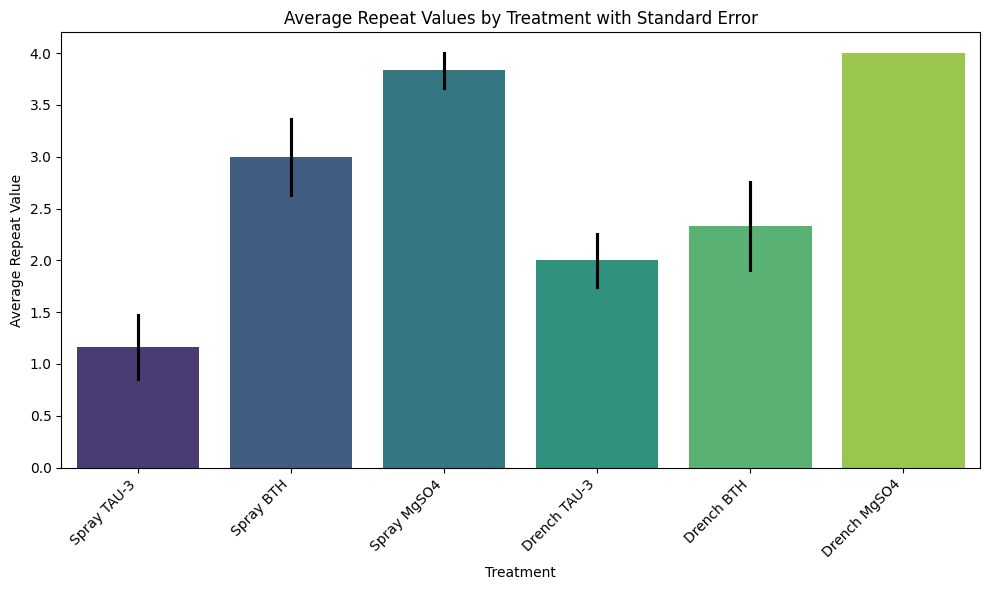

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame to long format for proper error bar calculation
df_melted = df.melt(id_vars=['Treatment'], value_vars=['repeat1', 'repeat2', 'repeat3', 'repeat4', 'repeat5', 'repeat6'],
                   var_name='Repeat_Number', value_name='Repeat_Value')

# Create the bar plot with error bars (standard error) and black error bar color
plt.figure(figsize=(10, 6))
sns.barplot(x='Treatment', y='Repeat_Value', data=df_melted, palette='viridis',
            errorbar='se', # Add standard error as error bars
            hue='Treatment', legend=False,
            err_kws={'color': 'black'}) # Set error bar color to black
plt.title('Average Repeat Values by Treatment with Standard Error')
plt.xlabel('Treatment')
plt.ylabel('Average Repeat Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [30]:
display(df)

,Treatment,repeat1,repeat2,repeat3,repeat4,repeat5,repeat6
0,Spray TAU-3,2,2,1,1,1,0
1,Spray BTH,2,2,3,4,3,4
2,Spray MgSO4,4,4,4,4,3,4
3,Drench TAU-3,2,2,3,2,2,1
4,Drench BTH,3,2,4,2,2,1
5,Drench MgSO4,4,4,4,4,4,4


In [31]:
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pandas as pd

# Perform One-Way ANOVA
# Convert 'Treatment' to categorical type if not already
df_melted['Treatment'] = df_melted['Treatment'].astype('category')

# Create a list of arrays, one for each treatment group
treatment_groups = [df_melted['Repeat_Value'][df_melted['Treatment'] == t] for t in df_melted['Treatment'].unique()]

f_statistic, p_value = stats.f_oneway(*treatment_groups)

print(f"ANOVA F-statistic: {f_statistic:.2f}")
print(f"ANOVA P-value: {p_value:.3f}")

# Perform Tukey's HSD post-hoc test if ANOVA is significant
if p_value < 0.05:
    print("\nANOVA is significant (p < 0.05). Performing Tukey's HSD post-hoc test...")
    tukey_results = pairwise_tukeyhsd(endog=df_melted['Repeat_Value'], groups=df_melted['Treatment'], alpha=0.05)
    print(tukey_results)

    # Generate alphabetical labels for groups that are not significantly different
    # Convert Tukey results table to a DataFrame for easier querying
    tukey_df = pd.DataFrame(data=tukey_results._results_table.data[1:],
                            columns=tukey_results._results_table.data[0])

    # Create a mapping for reject status between any two groups
    reject_map = {}
    for _, row in tukey_df.iterrows():
        g1, g2, reject = row['group1'], row['group2'], row['reject']
        reject_map[(g1, g2)] = reject
        reject_map[(g2, g1)] = reject # Store symmetrically for easy lookup

    treatments = sorted(df_melted['Treatment'].unique().tolist())
    num_treatments = len(treatments)

    # Initialize labels (use a set to avoid duplicate letters for a single treatment)
    labels = {t: set() for t in treatments}
    current_letter_idx = 0

    # Iterate through treatments to assign letters based on non-significant differences
    for i in range(num_treatments):
        t_i = treatments[i]
        if not labels[t_i]: # If t_i has not been assigned a letter from a previous grouping
            current_char = chr(ord('a') + current_letter_idx)

            # Assign this new letter to t_i
            labels[t_i].add(current_char)

            # Check all other treatments for non-significant difference with t_i
            for j in range(num_treatments):
                t_j = treatments[j]
                if t_i == t_j:
                    continue

                # If t_i and t_j are NOT significantly different, assign the same letter
                # Use .get() with a default of True (rejected) if a pair somehow isn't in the map
                if not reject_map.get((t_i, t_j), True):
                    labels[t_j].add(current_char)

            current_letter_idx += 1

    # Convert sets of letters to sorted strings for final labels (e.g., 'a', 'b', 'ab')
    final_labels = {t: "".join(sorted(list(l))) for t, l in labels.items()}

    # --- START OF LOGIC FOR RANKING LABELS BY MEAN VALUE (A=Highest Mean) ---

    # 1. Calculate the mean for each treatment (ensures it's up-to-date with df_melted)
    current_means = df_melted.groupby('Treatment')['Repeat_Value'].mean()

    # 2. Determine distinct label components (e.g., 'a', 'b' from 'a', 'b', 'ab')
    distinct_label_components = sorted(list(set("".join(final_labels.values()))))

    # 3. For each distinct component, find the maximum mean of any treatment associated with it
    component_ranking_means = {}
    for comp in distinct_label_components:
        treatments_with_comp = [t for t, label_str in final_labels.items() if comp in label_str]
        means_for_comp = [current_means[t] for t in treatments_with_comp]
        component_ranking_means[comp] = max(means_for_comp) if means_for_comp else 0

    # 4. Sort these components by their ranking mean in descending order
    sorted_components = sorted(component_ranking_means.items(), key=lambda item: item[1], reverse=True)

    # 5. Assign new capital letters (A, B, C...) based on this rank
    new_letter_map = {}
    for idx, (comp, _) in enumerate(sorted_components):
        new_letter_map[comp] = chr(ord('A') + idx)

    # 6. Apply this mapping to create the final ranked labels for each treatment
    ranked_final_labels = {}
    for treatment, original_label_str in final_labels.items():
        new_label_chars = []
        for char_comp in original_label_str:
            new_label_chars.append(new_letter_map[char_comp])
        # Sort the new label characters to maintain consistency (e.g., 'AB' instead of 'BA')
        ranked_final_labels[treatment] = "".join(sorted(new_label_chars))

    # Update df_melted['Label'] with these new ranked labels
    df_melted['Label'] = df_melted['Treatment'].map(ranked_final_labels)

    print("\nOriginal Alphabetical Labels (Tukey HSD):")
    print(final_labels)
    print("\nRanked Alphabetical Labels (by Mean Value, A=Highest Mean):")
    print(ranked_final_labels)

else:
    print("\nANOVA is not significant (p >= 0.05). No post-hoc test needed.")
    df_melted['Label'] = '' # No labels if not significant


ANOVA F-statistic: 14.49
ANOVA P-value: 0.000

ANOVA is significant (p < 0.05). Performing Tukey's HSD post-hoc test...
      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1       group2    meandiff p-adj   lower   upper  reject
----------------------------------------------------------------
  Drench BTH Drench MgSO4   1.6667 0.0038  0.4249  2.9084   True
  Drench BTH Drench TAU-3  -0.3333 0.9622 -1.5751  0.9084  False
  Drench BTH    Spray BTH   0.6667 0.5842 -0.5751  1.9084  False
  Drench BTH  Spray MgSO4      1.5 0.0109  0.2583  2.7417   True
  Drench BTH  Spray TAU-3  -1.1667 0.0752 -2.4084  0.0751  False
Drench MgSO4 Drench TAU-3     -2.0 0.0004 -3.2417 -0.7583   True
Drench MgSO4    Spray BTH     -1.0 0.1719 -2.2417  0.2417  False
Drench MgSO4  Spray MgSO4  -0.1667 0.9984 -1.4084  1.0751  False
Drench MgSO4  Spray TAU-3  -2.8333    0.0 -4.0751 -1.5916   True
Drench TAU-3    Spray BTH      1.0 0.1719 -0.2417  2.2417  False
Drench TAU-3  Spray MgSO4   1.8333 

/tmp/ipykernel_4165/1774276986.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  current_means = df_melted.groupby('Treatment')['Repeat_Value'].mean()


/tmp/ipykernel_4165/50713573.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  current_means = df_melted.groupby('Treatment')['Repeat_Value'].mean()
/tmp/ipykernel_4165/50713573.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  current_ses = df_melted.groupby('Treatment')['Repeat_Value'].sem()


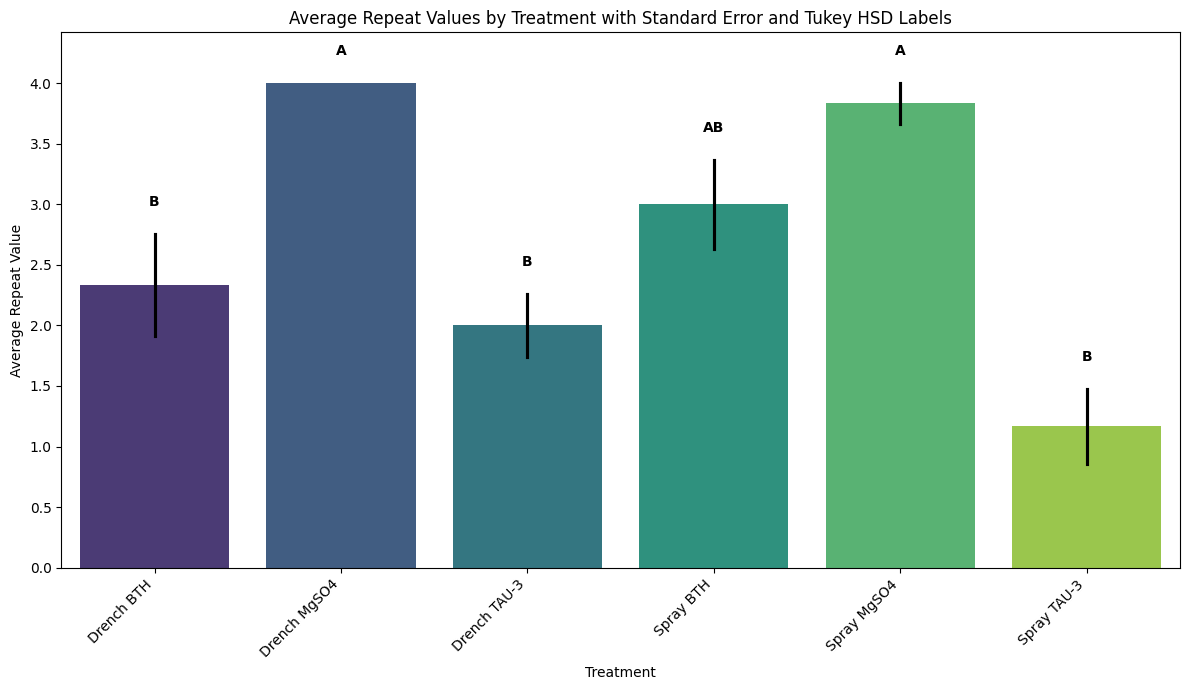

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Re-create the bar plot with alphabetical labels if generated
plt.figure(figsize=(12, 7))
ax = sns.barplot(x='Treatment', y='Repeat_Value', data=df_melted, palette='viridis',
            errorbar='se',
            hue='Treatment', legend=False,
            err_kws={'color': 'black'},
            order=treatments) # Ensure bar order matches the sorted treatments for labels

# Add alphabetical labels if they exist
if 'Label' in df_melted.columns and not df_melted['Label'].eq('').all():
    # Get the unique treatments and their corresponding labels
    unique_treatments = df_melted[['Treatment', 'Label']].drop_duplicates()
    # Create a dictionary for easier label lookup
    label_mapping = dict(zip(unique_treatments['Treatment'], unique_treatments['Label']))

    # Recalculate means and ses *here* to ensure they are consistent with the plotted data
    current_means = df_melted.groupby('Treatment')['Repeat_Value'].mean()
    current_ses = df_melted.groupby('Treatment')['Repeat_Value'].sem()

    max_y_for_labels = ax.get_ylim()[1] # Initialize with current max y-limit

    # Iterate over the bars (patches) in the bar plot
    for i, bar in enumerate(ax.patches):
        # Get the treatment name corresponding to this bar
        treatment_name = treatments[i]

        # Get the label for this treatment
        label = label_mapping.get(treatment_name, '')

        # Get the y-position for the label: top of the bar + standard error + a small offset
        mean_val = current_means.get(treatment_name, 0)
        se_val = current_ses.get(treatment_name, 0)

        # Determine the y-coordinate for the text
        # This will be the mean value + its standard error + a small buffer (5% of current max y-limit)
        y_pos = mean_val + se_val + (ax.get_ylim()[1] * 0.05)

        ax.text(bar.get_x() + bar.get_width() / 2, y_pos, label,
                ha='center', va='bottom', fontsize=10, weight='bold')

        # Update max_y_for_labels if this label's position is higher
        max_y_for_labels = max(max_y_for_labels, y_pos)

    # Set the y-axis limit to accommodate all labels with a small buffer
    ax.set_ylim(top=max_y_for_labels * 1.05)

plt.title('Average Repeat Values by Treatment with Standard Error and Tukey HSD Labels')
plt.xlabel('Treatment')
plt.ylabel('Average Repeat Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()